In [4]:
import numpy as np
import pandas as pd
import psycopg2 as ps

ModuleNotFoundError: No module named 'psycopg2'

In [3]:
conn = ps.connect(dbname="northwind3",
                  user="postgres",
                  password="Password.",
                  port = "5432")

NameError: name 'ps' is not defined

# ÜRÜN-FİYAT ANALİZİ CASE 1

In [3]:
sql = """WITH DATA AS (
        SELECT product_name,
               unit_price,
               CASE WHEN unit_price < 10                  THEN '0-10'
                    WHEN unit_price >= 10 AND unit_price < 20  THEN '10-20'
                    WHEN unit_price >= 20 AND unit_price < 30  THEN '20-30'
                    WHEN unit_price >= 30 AND unit_price < 40  THEN '30-40'
                    WHEN unit_price >= 40 AND unit_price < 50  THEN '40-50'
                    WHEN unit_price >= 50 AND unit_price < 60  THEN '50-60'
                    WHEN unit_price >= 60 AND unit_price < 70  THEN '60-70'
                    WHEN unit_price >= 70 AND unit_price < 80  THEN '70-80'
                    WHEN unit_price >= 80 AND unit_price < 90  THEN '80-90'
                    WHEN unit_price >= 90 AND unit_price < 100 THEN '90-100'
                    WHEN unit_price >= 100                THEN '100+'
                     END AS price_segment
          FROM products
       ) 
  SELECT 
       product_name,
       unit_price,
       price_segment,
       count(product_name) OVER (PARTITION BY price_segment) AS segment_product_count
  FROM DATA """

In [4]:
df = sqlio.read_sql_query(sql,conn)
df.head()

/var/folders/c0/xwksgvrj3076lmbh6gcrtv3h0000gn/T/ipykernel_2887/1600180838.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = sqlio.read_sql_query(sql,conn)


,product_name,unit_price,price_segment,segment_product_count
0,Tunnbröd,9.00,0-10,11
1,Konbu,6.00,0-10,11
2,Teatime Chocolate Biscuits,9.20,0-10,11
3,Rhönbräu Klosterbier,7.75,0-10,11
4,Tourtière,7.45,0-10,11


In [5]:
df.shape

(77, 4)

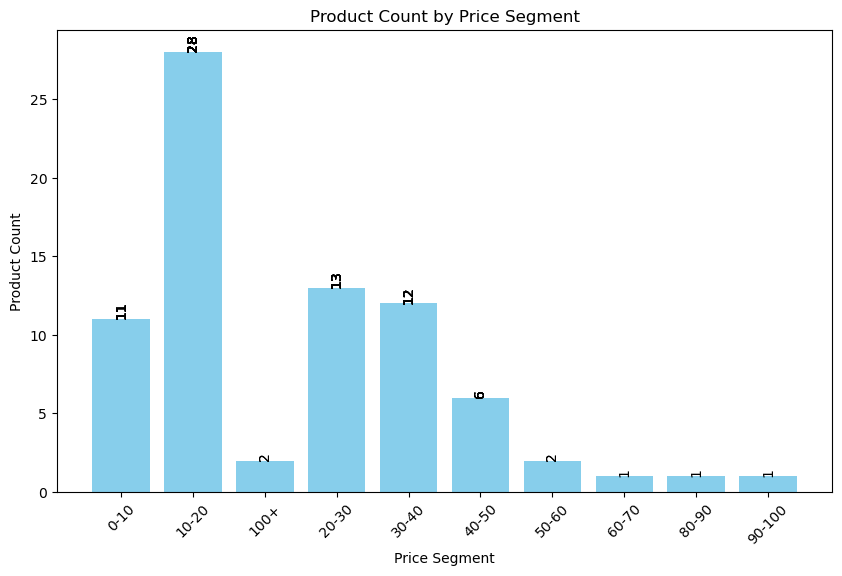

In [6]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))
bars = plt.bar(df['price_segment'], df['segment_product_count'], color='skyblue')
plt.xlabel('Price Segment')
plt.ylabel('Product Count')
plt.title('Product Count by Price Segment')
plt.xticks(rotation=45)


for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(int(bar.get_height())), 
             ha='center', va='bottom', fontsize=10, rotation=90)

plt.show()

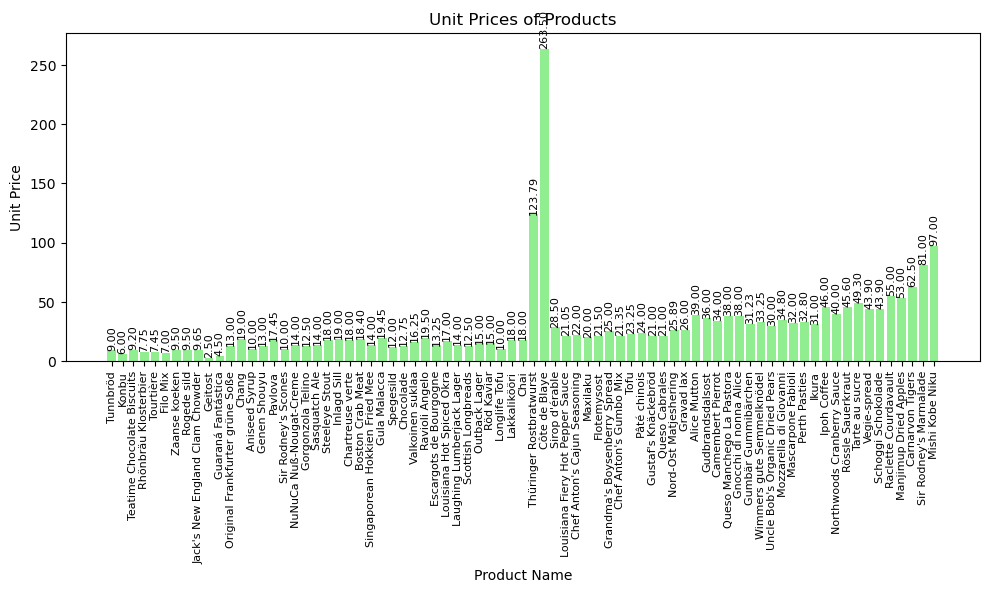

In [7]:
plt.figure(figsize=(10, 6))
bars = plt.bar(df['product_name'], df['unit_price'], color='lightgreen')
plt.xlabel('Product Name')
plt.ylabel('Unit Price')
plt.title('Unit Prices of Products')
plt.xticks(rotation=90, fontsize=8)  # 90 derece döndür ve yazı fontunu küçült

# Çubukların üzerine ürün fiyatlarını ekleyelim
for bar, price in zip(bars, df['unit_price']):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{price:.2f}', 
             ha='center', va='bottom', fontsize=8, rotation=90, color='black')

plt.tight_layout()  # Grafik öğelerinin sığmasını sağlar
plt.show()

# ÜRÜN-FİYAT ANALİZİ CASE 2#

In [8]:
sql2 = """WITH cte_price AS (
SELECT
d.product_id,
	p.product_name,
	ROUND(LEAD(d.unit_price) OVER (PARTITION BY p.product_name ORDER BY o.order_date)::NUMERIC,2) AS current_price,
	ROUND(LAG(d.unit_price) OVER (PARTITION BY p.product_name ORDER BY o.order_date)::NUMERIC,2) AS previous_unit_price
FROM products AS p
INNER JOIN order_details AS d
ON p.product_id = d.product_id
INNER JOIN orders AS o
ON d.order_id = o.order_id
)
SELECT
	c.product_name,
	c.current_price,
	c.previous_unit_price,
	ROUND(100*(c.current_price - c.previous_unit_price)/c.previous_unit_price) AS percentage_increase
FROM cte_price AS c
WHERE c.current_price != c.previous_unit_price
GROUP BY 
	c.product_name,
	c.current_price,
	c.previous_unit_price """

In [9]:
df2 = sqlio.read_sql_query(sql2,conn)
df2.head()

/var/folders/c0/xwksgvrj3076lmbh6gcrtv3h0000gn/T/ipykernel_2887/229322232.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df2 = sqlio.read_sql_query(sql2,conn)


,product_name,current_price,previous_unit_price,percentage_increase
0,Chef Anton's Gumbo Mix,21.35,17.0,26.0
1,Sasquatch Ale,14.00,11.2,25.0
2,Spegesild,12.00,9.6,25.0
3,Wimmers gute Semmelknödel,33.25,26.6,25.0
4,Carnarvon Tigers,62.50,50.0,25.0


In [11]:
df2.shape

(80, 4)

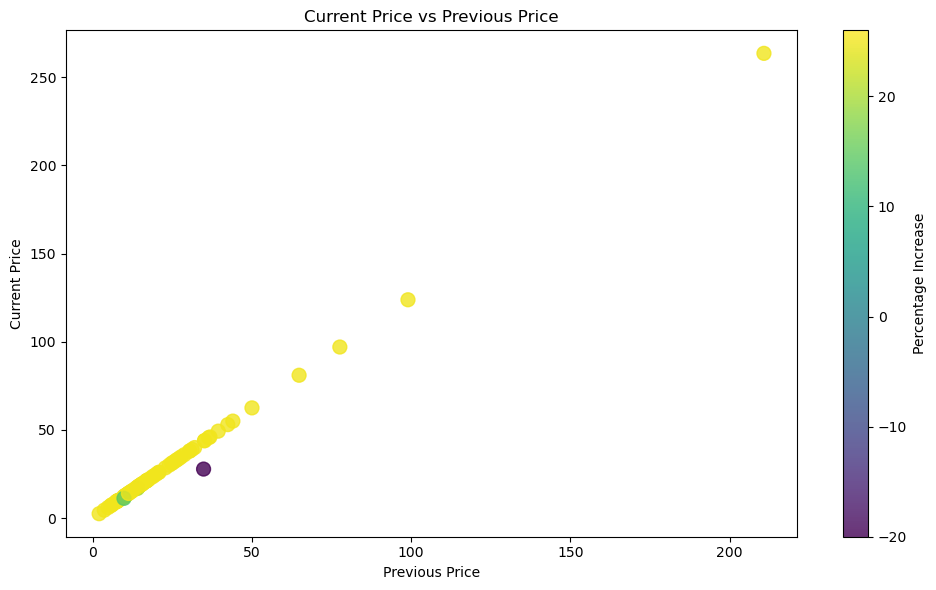

In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(df2['previous_unit_price'], df2['current_price'], c=df2['percentage_increase'], cmap='viridis', s=100, alpha=0.8)
plt.xlabel('Previous Price')
plt.ylabel('Current Price')
plt.title('Current Price vs Previous Price')
plt.colorbar(label='Percentage Increase')
plt.tight_layout()
plt.show()

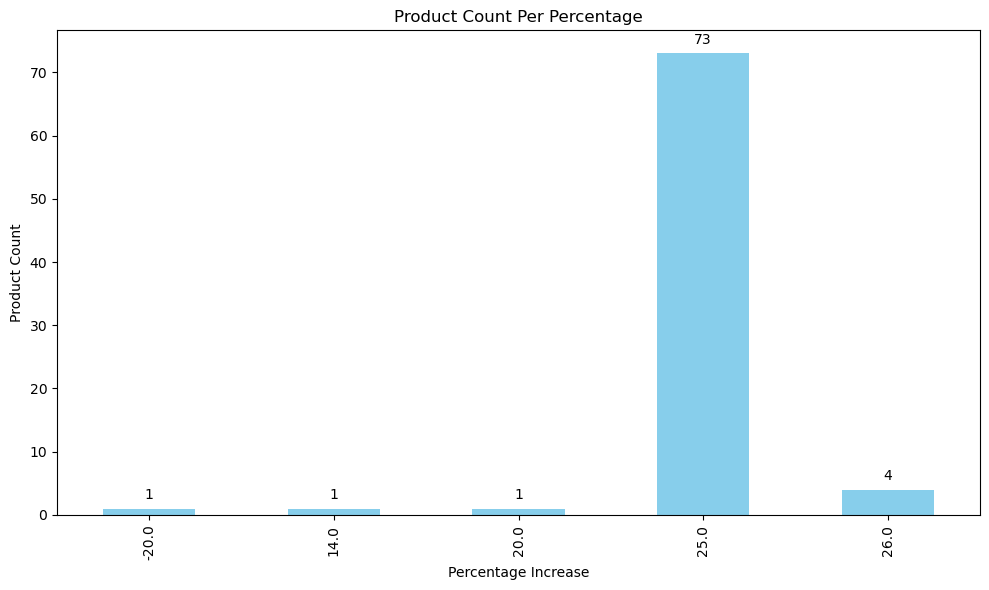

In [20]:
percentage_increases = sorted(df2['percentage_increase'].unique())

# Her percentage_increase değerine ait ürün sayısını hesaplıyoruz
product_counts = df2.groupby('percentage_increase')['product_name'].count()

# Çubuk grafiği oluşturuyoruz
plt.figure(figsize=(10, 6))
product_counts.plot(kind='bar', color='skyblue')
plt.title('Product Count Per Percentage')
plt.xlabel('Percentage Increase')
plt.ylabel('Product Count')
plt.xticks(range(len(percentage_increases)), percentage_increases)
plt.tight_layout()

# Ürün sayılarını çubukların üzerinde görüntülüyoruz
for i, count in enumerate(product_counts):
    plt.text(i, count + 1, str(count), ha='center', va='bottom', fontsize=10)

plt.show()

In [16]:
# Percentage increase değeri 25.00 olan ürünleri göstermek için datayı filtreliyoruz
selected_products = df2[df2['percentage_increase'] == 25.00]

# Seçilen ürünleri gösteren bir tablo oluşturuyoruz
selected_products_table = selected_products[['product_name', 'current_price', 'previous_unit_price']]

# Tabloyu görüntülüyoruz
print(selected_products_table)

                        product_name  current_price  previous_unit_price
1                      Sasquatch Ale          14.00                 11.2
2                          Spegesild          12.00                  9.6
3          Wimmers gute Semmelknödel          33.25                 26.6
4                   Carnarvon Tigers          62.50                 50.0
5                   Boston Crab Meat          18.40                 14.7
..                               ...            ...                  ...
74                       Ipoh Coffee          46.00                 36.8
75             Nord-Ost Matjeshering          25.89                 20.7
77                 Camembert Pierrot          34.00                 27.2
78           NuNuCa Nuß-Nougat-Creme          14.00                 11.2
79  Louisiana Fiery Hot Pepper Sauce          21.05                 16.8

[73 rows x 3 columns]


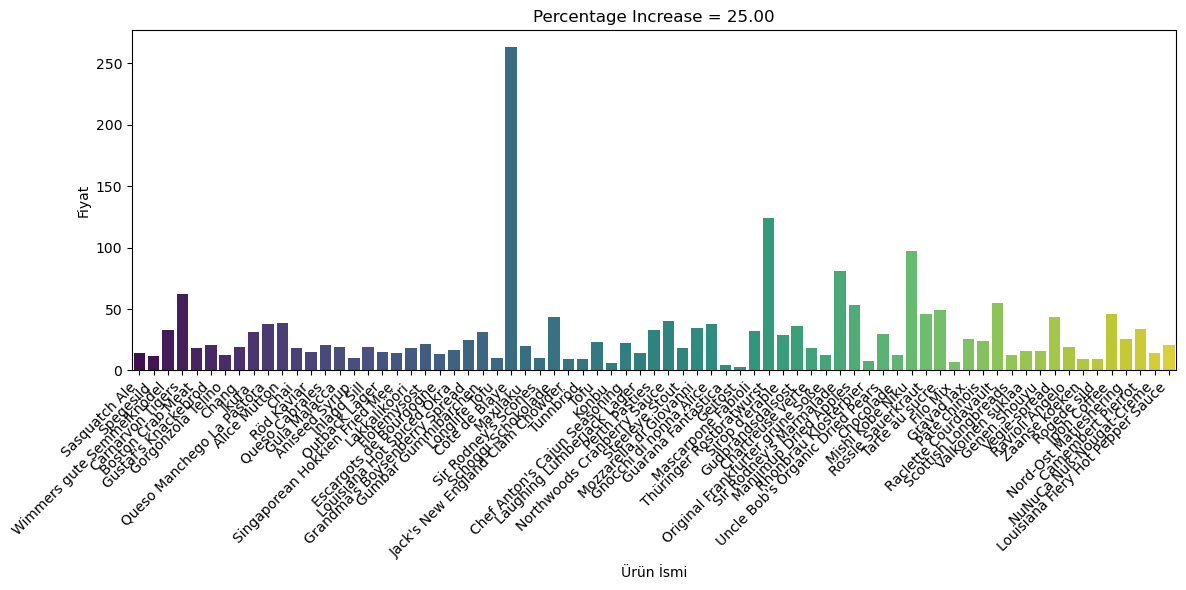

In [21]:
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(data=selected_products, x='product_name', y='current_price', palette='viridis')
plt.title('Percentage Increase = 25.00')
plt.xlabel('Ürün İsmi')
plt.ylabel('Fiyat')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()